# **NREL S809 Airfoil**

NREL's S809 airfoil has a 21% thickness and is designed specifically for use in horizontal-axis wind turbines. In this Quick Start we will use a quasi-3D model created in Engineering Sketch Pad (ESP) using the S809 airfoil coordinates. More information about NREL's S809 airfoil can be found in this [technical report](https://www.osti.gov/biblio/534484) by Sandia National Laboratories.

This model differs from other Quick Start examples as it simplifies geometry and mesh to mimic a 2D airfoil profile. SlipWall boundary condition is applied at both spanwise ends of the airfoil, effectively creating an infinite span geometry.

Flow conditions are:
- Reynolds = 2e+06
- Mach = 0.15
- Angle of Attack = 5.13°

## Imports

We begin by importing `flow360` and `NRELS809`.

In [1]:
# Flow360 imports
import flow360 as fl
from flow360.examples import NRELS809

# We also import and change the log settings to only see ones of level INFO or higher
from flow360.log import log, set_logging_level
log.log_to_file = False
set_logging_level("INFO")

To download the geometry file from the server, use `get_files()` method.

In [2]:
NRELS809.get_files()

The geometry file is also available for download by clicking this [link](https://simcloud-public-1.s3.amazonaws.com/s809/s809.csm).project = fl.Project.from_file(NRELS809.geometry, name="NREL S809 Quick Start")

## Project Creation

We create a project variable that will be used for uploading the geometry, and later generating meshes and running the case.

In [3]:
project = fl.Project.from_file(NRELS809.geometry, name="NREL S809 Quick Start")

Output()

[10:34:14] INFO: Geometry successfully submitted:                                                                  
                   name   = NREL S809 Quick Start                                                                  
                   id     = geo-f632af0f-bd88-44c3-95e3-8cff5c8e096b                                               
                   status = uploaded                                                                               
           

           INFO: Waiting for geometry to be processed.

[10:34:59] WARNING: Could not find face grouping info in the draft's simulation settings. Please remember to group 
           them if relevant features are used.

           WARNING: Could not find edge grouping info in the draft's simulation settings. Please remember to group 
           them if relevant features are used.

Geometry can be assigned to a variable.

In [4]:
geometry = project.geometry

Now we will show groupings and group the faces and edges.

In [5]:
# show face and edge groupings
geometry.show_available_groupings(verbose_mode=True)
geometry.group_faces_by_tag("faceName")
geometry.group_edges_by_tag("edgeName")

[10:35:05] INFO:  >> Available attribute tags for grouping **faces**:

           INFO:     >> Tag 0: faceName. Grouping with this tag results in:

           INFO:         >> Group 0: wing

           INFO:            IDs: ['body0001_face0001', 'body0001_face0002', 'body0001_face0004',                   
           'body0001_face0005']

           INFO:         >> Group 1: wingTrailing

...

           INFO:            IDs: ['body0001_edge0003', 'body0001_edge0004', 'body0001_edge0006',                   
           'body0001_edge0007']

           INFO:         >> Group 3: body0001_edge0008

           INFO:            IDs: ['body0001_edge0008']

           INFO:         >> Group 4: body0001_edge0009

           INFO:            IDs: ['body0001_edge0009']

## Simulation parameters

Using `SimulationParams` class we create `params`, which will contain settings for our simulation.

In [6]:
# Use SI units
with fl.SI_unit_system:

    # Cylinder entities for mesh refinement
    cylinders = [
        fl.Cylinder(
            name=f"cylinder{i+1}",
            axis=[0, 1, 0],
            center=[0.7, 0.5, 0],
            outer_radius=outer_radius,
            height=1.0,
        )
        for i, outer_radius in enumerate([1.1, 2.2, 3.3, 4.5])
    ]
    cylinder5 = fl.Cylinder(
        name="cylinder5", axis=[-1, 0, 0], center=[2, 0.5, 0], outer_radius=6.5, height=14.5
    )

    # Farfield entity for volume zones and boundary conditions
    farfield = fl.AutomatedFarfield(name="farfield", method="quasi-3d")

    # Simulation parameters
    params = fl.SimulationParams(

        # Meshing parameters
        meshing=fl.MeshingParams(

            # Default meshing settings
            defaults=fl.MeshingDefaults(
                surface_edge_growth_rate=1.08,
                surface_max_edge_length=0.58,
                curvature_resolution_angle=10 * fl.u.deg,
                boundary_layer_growth_rate=1.04,
                boundary_layer_first_layer_thickness=4.29e-06,
            ),

            # New volume zones
            volume_zones=[farfield],

            # Local settings for refining the mesh
            refinements=[
                fl.UniformRefinement(name="refinement1", spacing=0.08, entities=[cylinders[0]]),
                fl.UniformRefinement(name="refinement2", spacing=0.13, entities=[cylinders[1]]),
                fl.UniformRefinement(name="refinement3", spacing=0.2, entities=[cylinders[2]]),
                fl.UniformRefinement(name="refinement4", spacing=0.25, entities=[cylinders[3]]),
                fl.UniformRefinement(name="refinement5", spacing=0.29, entities=[cylinder5]),
                fl.SurfaceRefinement(name="wing", max_edge_length=0.4, faces=[geometry["wing"]]),
                fl.SurfaceEdgeRefinement(
                    name="edges",
                    method=fl.HeightBasedRefinement(value=4e-04),
                    edges=[
                        geometry["wingtrailingEdge"],
                        geometry["wingleadingEdge"],
                    ],
                ),
                fl.SurfaceEdgeRefinement(
                    name="symmetry", method=fl.ProjectAnisoSpacing(), edges=[geometry["symmetry"]]
                ),
            ],
        ),

        # Reference geometrical values
        reference_geometry=fl.ReferenceGeometry(
            moment_center=[0.25, 0, 0], moment_length=[1, 1, 1], area=0.01
        ),

        # Operating conditions of the flow in the freestream
        operating_condition=fl.operating_condition_from_mach_reynolds(
            mach=0.15,
            reynolds=2e06,
            project_length_unit=1 * fl.u.m,
            temperature=293.15,
            alpha=5.13 * fl.u.deg,
            beta=0 * fl.u.deg,
        ),

        # Time stepping method set to steady state
        time_stepping=fl.Steady(
            max_steps=5000, CFL=fl.RampCFL(initial=20, final=200, ramp_steps=100)
        ),

        # Models with boundary conditions and solver settings.
        models=[
            fl.Fluid(
                navier_stokes_solver=fl.NavierStokesSolver(
                    absolute_tolerance=1e-11,
                    linear_solver=fl.LinearSolver(max_iterations=35),
                    kappa_MUSCL=0.33,
                ),
                turbulence_model_solver=fl.SpalartAllmaras(
                    absolute_tolerance=1e-10,
                    linear_solver=fl.LinearSolver(max_iterations=25),
                ),
            ),
            fl.Wall(surfaces=[geometry["*"]], name="wall"),
            fl.Freestream(surfaces=farfield.farfield, name="Freestream"),
            fl.SlipWall(surfaces=farfield.symmetry_planes, name="slipwall"),

        ],

        # Outputs for post-processing purposes
        outputs=[
            fl.VolumeOutput(
                name="fl.VolumeOutput",
                output_fields=[
                    "primitiveVars",
                    "Mach",
                ],
            ),
            fl.SurfaceOutput(
                name="fl.SurfaceOutput",
                surfaces=geometry["*"],
                output_fields=["primitiveVars", "Cp", "Cf"],
            ),
        ],
    )

[10:35:06] INFO: using: SI unit system for unit inference.

           INFO: Density and viscosity were calculated based on input data, ThermalState will be automatically     
           created.

## Running the case

Now that we have all of our `params` set up, we can run the case to obtain a solution.

In [7]:
project.run_case(params=params, name="Case of NREL S809 Quick Start")

## Post processing

After the case is finished calculating, we can download values of interest and plot them for better visualization.

In [8]:
case = project.case

# Wait for the case to finish
case.wait()

Convert the results into a pandas dataframe format.

In [9]:
nonlinear_residuals = case.results.nonlinear_residuals
nonlinear_residuals = nonlinear_residuals.as_dataframe()

cfl = case.results.cfl
cfl = cfl.as_dataframe()

total_forces = case.results.total_forces
total_forces = total_forces.as_dataframe()

Output()

[11:16:22] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpbkreb1mn/ef712b62-96f5-45aa-a30e-11a24b35ddb1.csv

Output()

[11:16:23] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpbkreb1mn/d308c5d7-9e36-4906-9d85-501d84bc1f48.csv

Output()

[11:16:25] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmpbkreb1mn/bde5c514-f2a0-469f-a6cd-7d97f1c7ef2c.csv

We can look at the convergence of the solution by creating the following plot.

<Axes: xlabel='Pseudo Step', ylabel='residuals'>

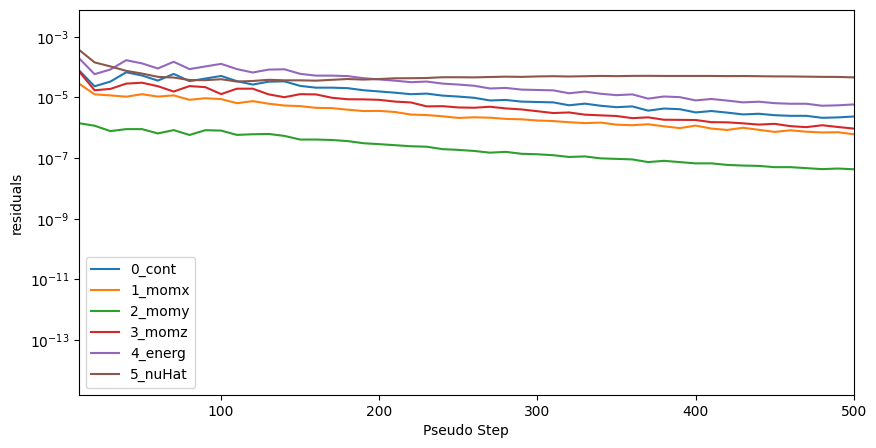

In [10]:
nonlinear_residuals.plot(x='pseudo_step',
                         y=["0_cont", "1_momx", "2_momy", "3_momz", "4_energ", "5_nuHat"],
                         logy=True,
                         xlim=(10, 500),
                         xlabel="Pseudo Step",
                         ylabel="residuals",
                         figsize=(10, 5)
)

For this case, the CFL values will have a less steep curve due to a relatively high initial value.

<Axes: xlabel='pseudo_step'>

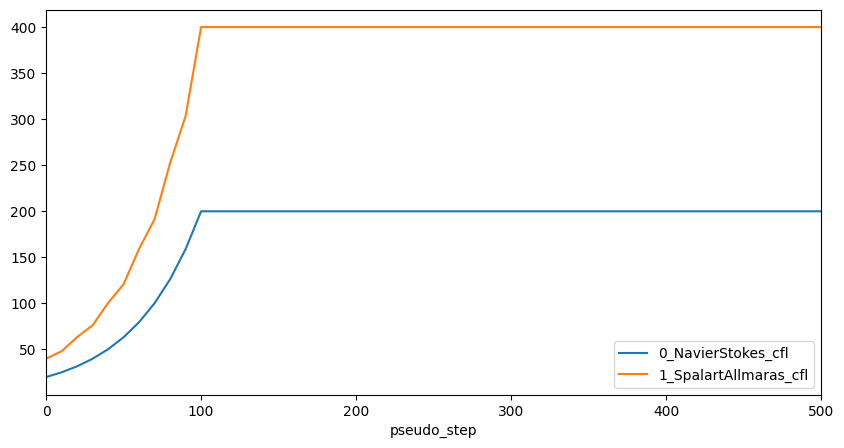

In [11]:
cfl.plot(x='pseudo_step', y=["0_NavierStokes_cfl", "1_SpalartAllmaras_cfl"], xlim=(0, 500), figsize=(10, 5))

To view the forces and moments, you can plot them.

<Axes: xlabel='Pseudo Step'>

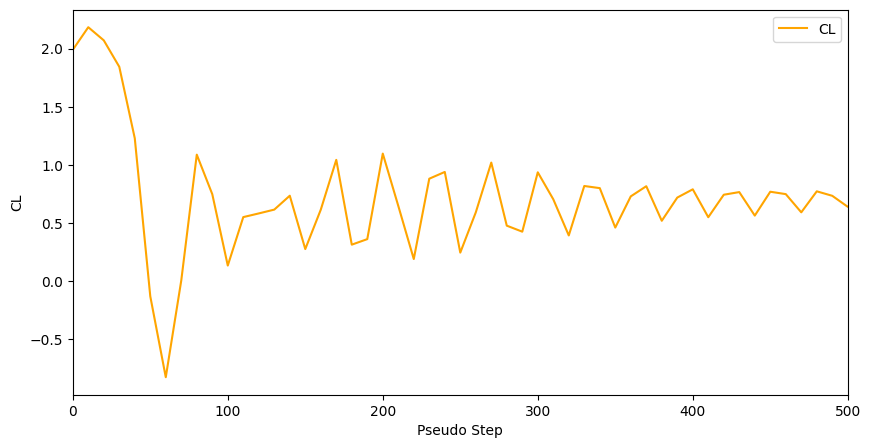

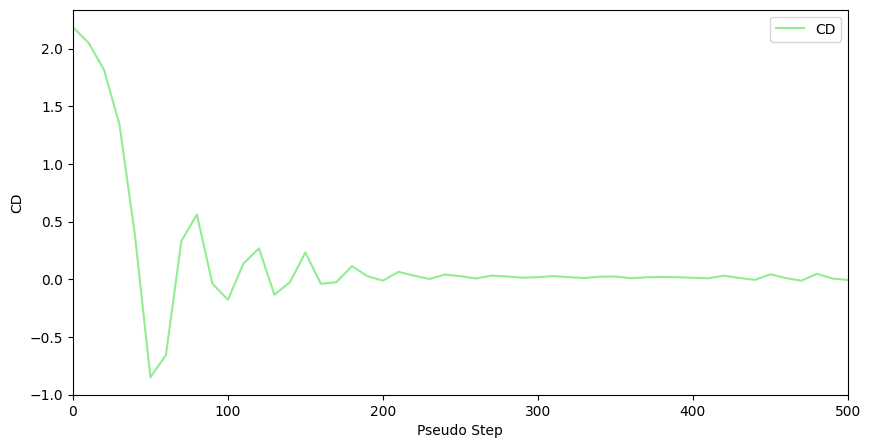

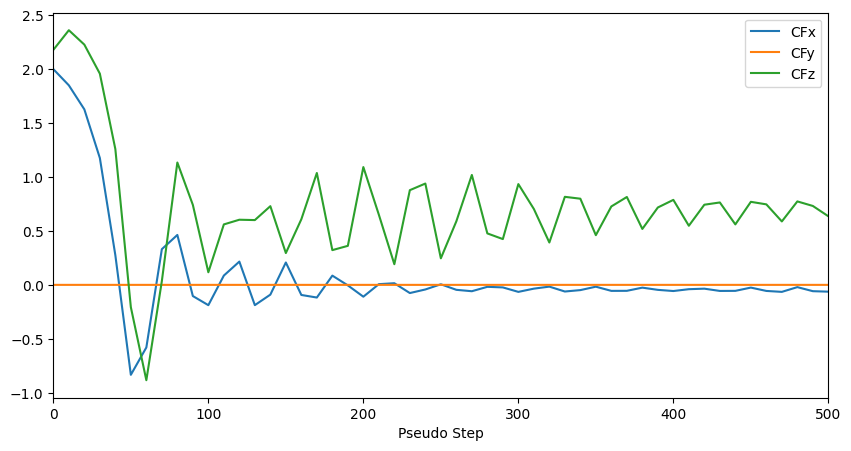

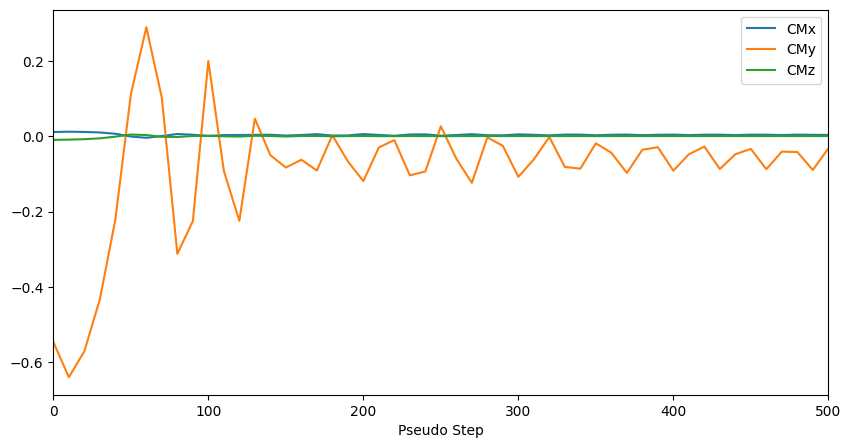

In [12]:
total_forces.plot(x="pseudo_step",
                  y="CL",
                  xlabel="Pseudo Step",
                  ylabel="CL",
                  xlim=(0, 500),
                  figsize=(10, 5),
                  style="orange"
)
total_forces.plot(x="pseudo_step",
                  y="CD",
                  xlabel="Pseudo Step",
                  ylabel="CD",
                  xlim=(0, 500),
                  figsize=(10, 5),
                  style="lightgreen",
)
total_forces.plot(x="pseudo_step",
                  y=["CFx", "CFy", "CFz"],
                  xlabel="Pseudo Step",
                  xlim=(0, 500),
                  figsize=(10, 5),
)
total_forces.plot(x="pseudo_step",
                  y=["CMx", "CMy", "CMz"],
                  xlabel="Pseudo Step",
                  xlim=(0, 500),
                  figsize=(10, 5),
)

For more information about this Quick Start case, visit the [Flow360 documentation](https://docs.flexcompute.com/projects/flow360/en/latest/quickStart/QuasiAirfoil_AutomatedMeshing/QuasiAirfoil_AutomatedMeshing.html#).